In [1]:
import numpy as np, pickle, scipy.sparse as sp
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, classification_report,
confusion_matrix, roc_auc_score, roc_curve)
print("Ready!")

Ready!


In [2]:
X_train = sp.load_npz('saved_models/X_train.npz')
X_test = sp.load_npz('saved_models/X_test.npz')
y_train = np.load('saved_models/y_train.npy')
y_test = np.load('saved_models/y_test.npy')
print("Data loaded!")

Data loaded!


In [3]:
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train, y_train)
print("Naive Bayes trained!")

Naive Bayes trained!


In [4]:
y_pred = nb_model.predict(X_test)
y_prob = nb_model.predict_proba(X_test)[:,1]
acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
print(f"Accuracy : {acc:.4f} ({acc*100:.2f}%)")
print(f"ROC-AUC : {roc_auc:.4f}")
print(classification_report(y_test, y_pred,
target_names=['Fake','Real']))

Accuracy : 0.9618 (96.18%)
ROC-AUC : 0.9866
              precision    recall  f1-score   support

        Fake       0.97      0.96      0.96      4562
        Real       0.96      0.96      0.96      4283

    accuracy                           0.96      8845
   macro avg       0.96      0.96      0.96      8845
weighted avg       0.96      0.96      0.96      8845



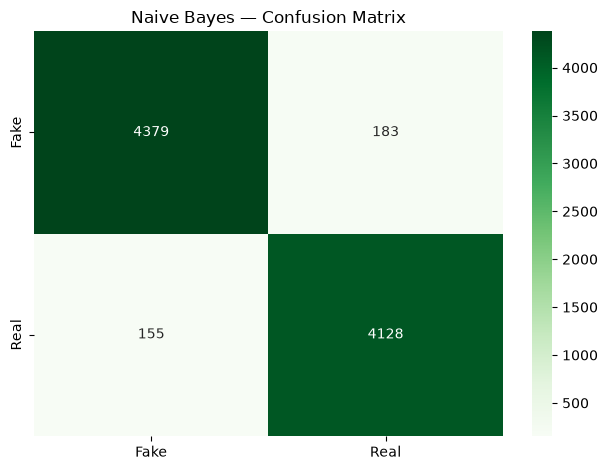

In [5]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
xticklabels=['Fake','Real'],
yticklabels=['Fake','Real'])
plt.title('Naive Bayes — Confusion Matrix')
plt.tight_layout()
plt.savefig('nb_confusion_matrix.png', dpi=150)
plt.show()

In [6]:
pickle.dump(nb_model,
open('saved_models/nb_model.pkl','wb'))
print("Naive Bayes model saved!")

Naive Bayes model saved!
